(bg_bb)=

# The BG/BB Model for Discrete-Time Customer Lifetime Value

In this notebook we show how to fit a BG/BB (beta-geometric/beta-binomial) model in PyMC-Marketing. The model is presented in the paper: Fader, P. S., Hardie, B. G., & Shang, J. (2010). [Customer-Base Analysis in a Discrete-Time Noncontractual Setting. Marketing Science, 29(6), 1086-1108.](https://www.brucehardie.com/papers/020/fader_et_al_mksc_10.pdf)

The BG/BB model is the discrete-time analog of the Pareto/NBD and BG/NBD models. Use it when customers can only transact at fixed, discrete opportunities, for example a yearly donation campaign, an annual conference, or a weekly event. At each opportunity a customer either transacts or does not, so the model does not count purchases per period. It only asks whether a transaction occurred.

## Model

The paper states the model with six assumptions:

1. A customer is "alive" for some period of time, then becomes permanently inactive.
2. While alive, the customer transacts at any given opportunity with probability $p$.
3. An alive customer becomes inactive at the beginning of a transaction opportunity with probability $\theta$. The unobserved lifetime therefore follows a geometric distribution.
4. Heterogeneity in $p$ across customers follows a $\text{Beta}(\alpha, \beta)$ distribution.
5. Heterogeneity in $\theta$ across customers follows a $\text{Beta}(\gamma, \delta)$ distribution.
6. $p$ and $\theta$ vary independently across customers.

The model has four population parameters: $\alpha$ and $\beta$ for the purchase process, and $\gamma$ and $\delta$ for the dropout process. Like the other CLV models, it only needs three numbers per customer: frequency, recency, and the number of transaction opportunities $T$.

## Prepare Notebook

In [1]:
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pymc_extras.prior import Prior

from pymc_marketing import clv

# Plotting configuration
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
seed = sum(map(ord, "BG/BB Model"))
rng = np.random.default_rng(seed)

## Read Data

We use the donations dataset from the paper. A nonprofit organization in the midwestern United States acquired 11,104 first-time supporters in 1995. In each of the following six years (1996 to 2001), every supporter either made a donation or did not.

In [3]:
data_path = "https://raw.githubusercontent.com/pymc-labs/pymc-marketing/main/data/bgbb_donations.csv"

data = pd.read_csv(data_path)

data.head()

,customer_id,frequency,recency,T
0,0,0,0,6
1,1,0,0,6
2,2,0,0,6
3,3,0,0,6
4,4,0,0,6


Each row is one donor:

- `frequency` is the number of years with a repeat donation (0 to 6).
- `recency` is the transaction opportunity of the last repeat donation, counted from the first donation in 1995. A donor with `recency=6` donated in 2001. A donor with `frequency=0` has `recency=0`.
- `T` is the number of transaction opportunities. The model requires the same `T` for every customer, which here is the six years from 1996 to 2001.

In [4]:
data["T"].unique()

array([6])

Because $T$ is the same for everyone and both `frequency` and `recency` are small integers, the 11,104 donors fall into only 22 distinct (frequency, recency) patterns. The table below counts the donors in each pattern.

In [5]:
data.pivot_table(
    index="frequency", columns="recency", values="customer_id", aggfunc="count"
).fillna(0).astype(int)

recency,0,1,2,3,4,5,6
frequency,,,,,,,
0,3464,0,0,0,0,0,0
1,0,1091,277,129,78,119,129
2,0,0,613,255,155,173,234
3,0,0,0,322,181,225,357
4,0,0,0,0,240,284,512
5,0,0,0,0,0,335,728
6,0,0,0,0,0,0,1203


## Reproduce the Paper with MAP

The paper estimates the four parameters by maximum likelihood. We get the same point estimates with a MAP fit and flat priors on $\alpha$, $\beta$, $\gamma$ and $\delta$.

In [6]:
flat_model_config = {
    "alpha": Prior("HalfFlat"),
    "beta": Prior("HalfFlat"),
    "gamma": Prior("HalfFlat"),
    "delta": Prior("HalfFlat"),
}

model_map = clv.BetaGeoBetaBinomModel(model_config=flat_model_config)
model_map.fit(data=data, method="map")
map_summary = model_map.fit_summary()
map_summary

Output()

alpha     1.2
beta     0.75
gamma    0.66
delta     2.8
Name: value, dtype: str

The estimates reported in the paper (Figure 2 and Table 4) are $\alpha = 1.204$, $\beta = 0.750$, $\gamma = 0.657$ and $\delta = 2.783$.

In [7]:
paper_estimates = pd.Series(
    {"alpha": 1.204, "beta": 0.750, "gamma": 0.657, "delta": 2.783}, name="paper"
)
map_estimates = pd.Series(
    {
        var_name: model_map.fit_result[var_name].item()
        for var_name in paper_estimates.index
    },
    name="map",
)
pd.concat([paper_estimates, map_estimates], axis=1).round(3)

,paper,map
alpha,1.204,1.204
beta,0.750,0.750
gamma,0.657,0.657
delta,2.783,2.784


## Full Bayesian Fit

For the full Bayesian model we use the default priors. Instead of placing priors on $\alpha$ and $\beta$ directly, the model uses the mean $\phi$ and the concentration $\kappa$ of the beta distribution:

$$
\alpha = \phi_{\text{purchase}} \kappa_{\text{purchase}}, \qquad \beta = (1 - \phi_{\text{purchase}}) \kappa_{\text{purchase}}
$$

with $\phi \sim \text{Uniform}(0, 1)$ and $\kappa \sim \text{Pareto}(1, 1)$. The dropout parameters $\gamma$ and $\delta$ use the same form with $\phi_{\text{dropout}}$ and $\kappa_{\text{dropout}}$.

In [8]:
model = clv.BetaGeoBetaBinomModel()
model.default_model_config

{'phi_purchase': Prior("Uniform", lower=0, upper=1),
 'kappa_purchase': Prior("Pareto", alpha=1, m=1),
 'phi_dropout': Prior("Uniform", lower=0, upper=1),
 'kappa_dropout': Prior("Pareto", alpha=1, m=1)}

In [9]:
sample_kwargs = {
    "draws": 1_000,
    "tune": 1_000,
    "chains": 4,
    "target_accept": 0.9,
    "random_seed": rng,
}

model.fit(data=data, **sample_kwargs)

NUTS[nutpie]: [phi_purchase, kappa_purchase, phi_dropout, kappa_dropout]


Output()

Output()

/home/pablo/Documents/repos-mios/pymc-marketing/.claude/worktrees/issue-1407-bgbb-notebook/.venv/lib/python3.13/site-packages/pymc/sampling/deterministic.py:143: FutureWarning: `merge_dataset` is deprecated and will be removed in a future release. Use `extend_dataset=True` to add the deterministics to the original dataset, passing a `.copy()` of it if it should not be mutated.
  warnings.warn(


<xarray.DataTree>
Group: /
│   Attributes:
│       id:              e39fe3be1a273fa5
│       model_type:      BG/BB
│       version:         None
│       sampler_config:  {}
│       model_config:    {"phi_purchase": {"dist": "Uniform", "kwargs": {"lower":...
├── Group: /posterior
│       Dimensions:         (chain: 4, draw: 1000)
│       Coordinates:
│         * chain           (chain) int64 32B 0 1 2 3
│         * draw            (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│       Data variables:
│           phi_purchase    (chain, draw) float64 32kB 0.6158 0.6153 ... 0.616 0.6126
│           kappa_purchase  (chain, draw) float64 32kB 1.804 1.804 1.836 ... 2.033 1.833
│           phi_dropout     (chain, draw) float64 32kB 0.1842 0.1857 ... 0.1946 0.1868
│           kappa_dropout   (chain, draw) float64 32kB 3.516 3.504 3.746 ... 3.419 3.454
│           alpha           (chain, draw) float64 32kB 1.111 1.11 1.117 ... 1.252 1.123
│           beta            (chain, draw) float64 32kB 0.6931 0.6939 ... 0.7806 0.7102
│           gamma           (chain, draw) float64 32kB 0.6475 0.6506 ... 0.6653 0.6454
│           delta           (chain, draw) float64 32kB 2.869 2.853 3.045 ... 2.754 2.809
│       Attributes:
│           created_at:                 2026-09-28T18:08:16.338834+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              521.8884134292603
│           tuning_steps:               1000
│           pymc_marketing_version:     1.1.0
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 3 3 2 2 1 ... 2 2 3 3 3
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 0.5293 ... 0.5142
│           transformation_update_id  (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 32kB 0.5121 ... 0.5498
│           mean_tree_accept          (chain, draw) float64 32kB 0.8976 1.0 ... 0.9927
│           ...                        ...
│           fisher_distance           (chain, draw) float64 32kB 11.73 7.357 ... 3.564
│           transformation_index      (chain, draw) int64 32kB 849 849 849 ... 849 849
│           diverging                 (chain, draw) bool 4kB False False ... False False
│           divergence_draw           (chain, draw) uint64 32kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 32kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 32kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-28T18:08:16.329724+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.2.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-09-28T18:08:16.335796+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:          

In [10]:
model.fit_summary(var_names=["alpha", "beta", "gamma", "delta"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,1.205,0.068,1.1,1.3,1213,1586,1.00,0.0019,0.0013
beta,0.75,0.0287,0.71,0.8,1921,2469,1.00,0.00066,0.00045
gamma,0.658,0.051,0.58,0.74,1413,2177,1.00,0.0013,0.001
delta,2.79,0.32,2.3,3.3,1134,1639,1.00,0.0095,0.0079


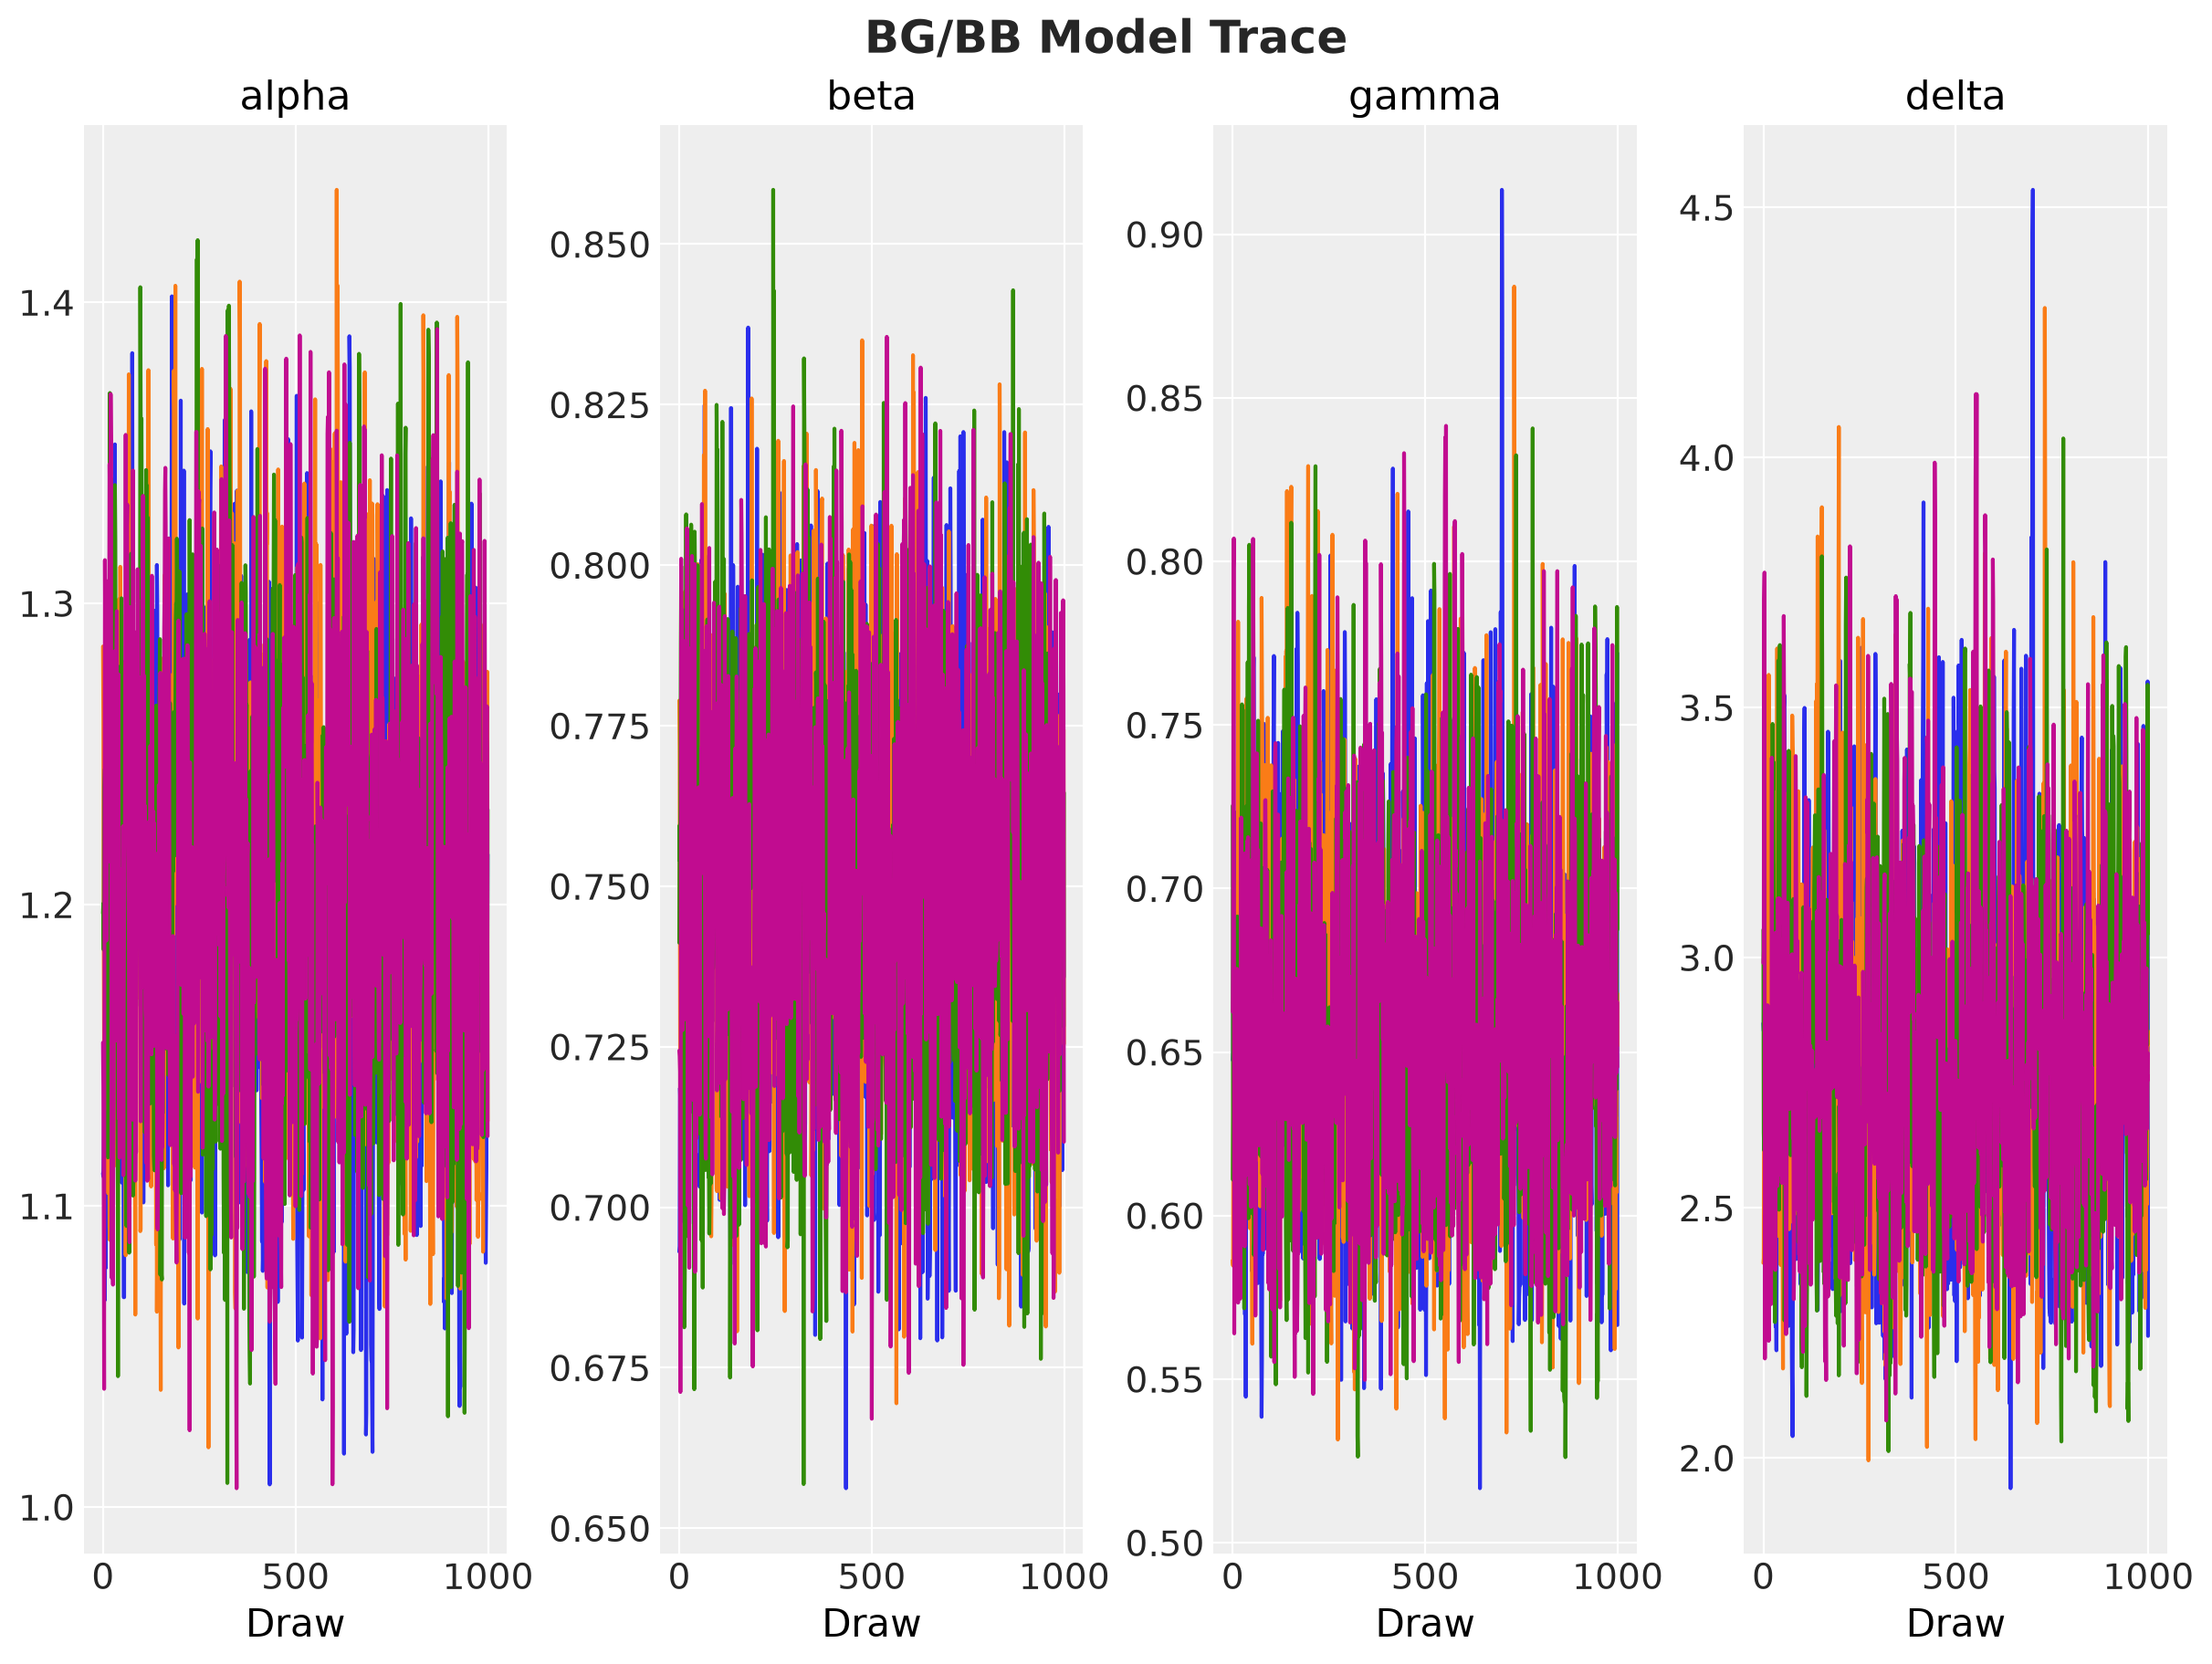

In [11]:
azp.plot_trace(
    model.idata,
    var_names=["alpha", "beta", "gamma", "delta"],
    figure_kwargs={"figsize": (12, 9), "layout": "constrained"},
)
plt.gcf().suptitle("BG/BB Model Trace", fontsize=18, fontweight="bold");

With 11,104 donors, the posterior distributions are narrow and centered on the MAP estimates (dashed lines).

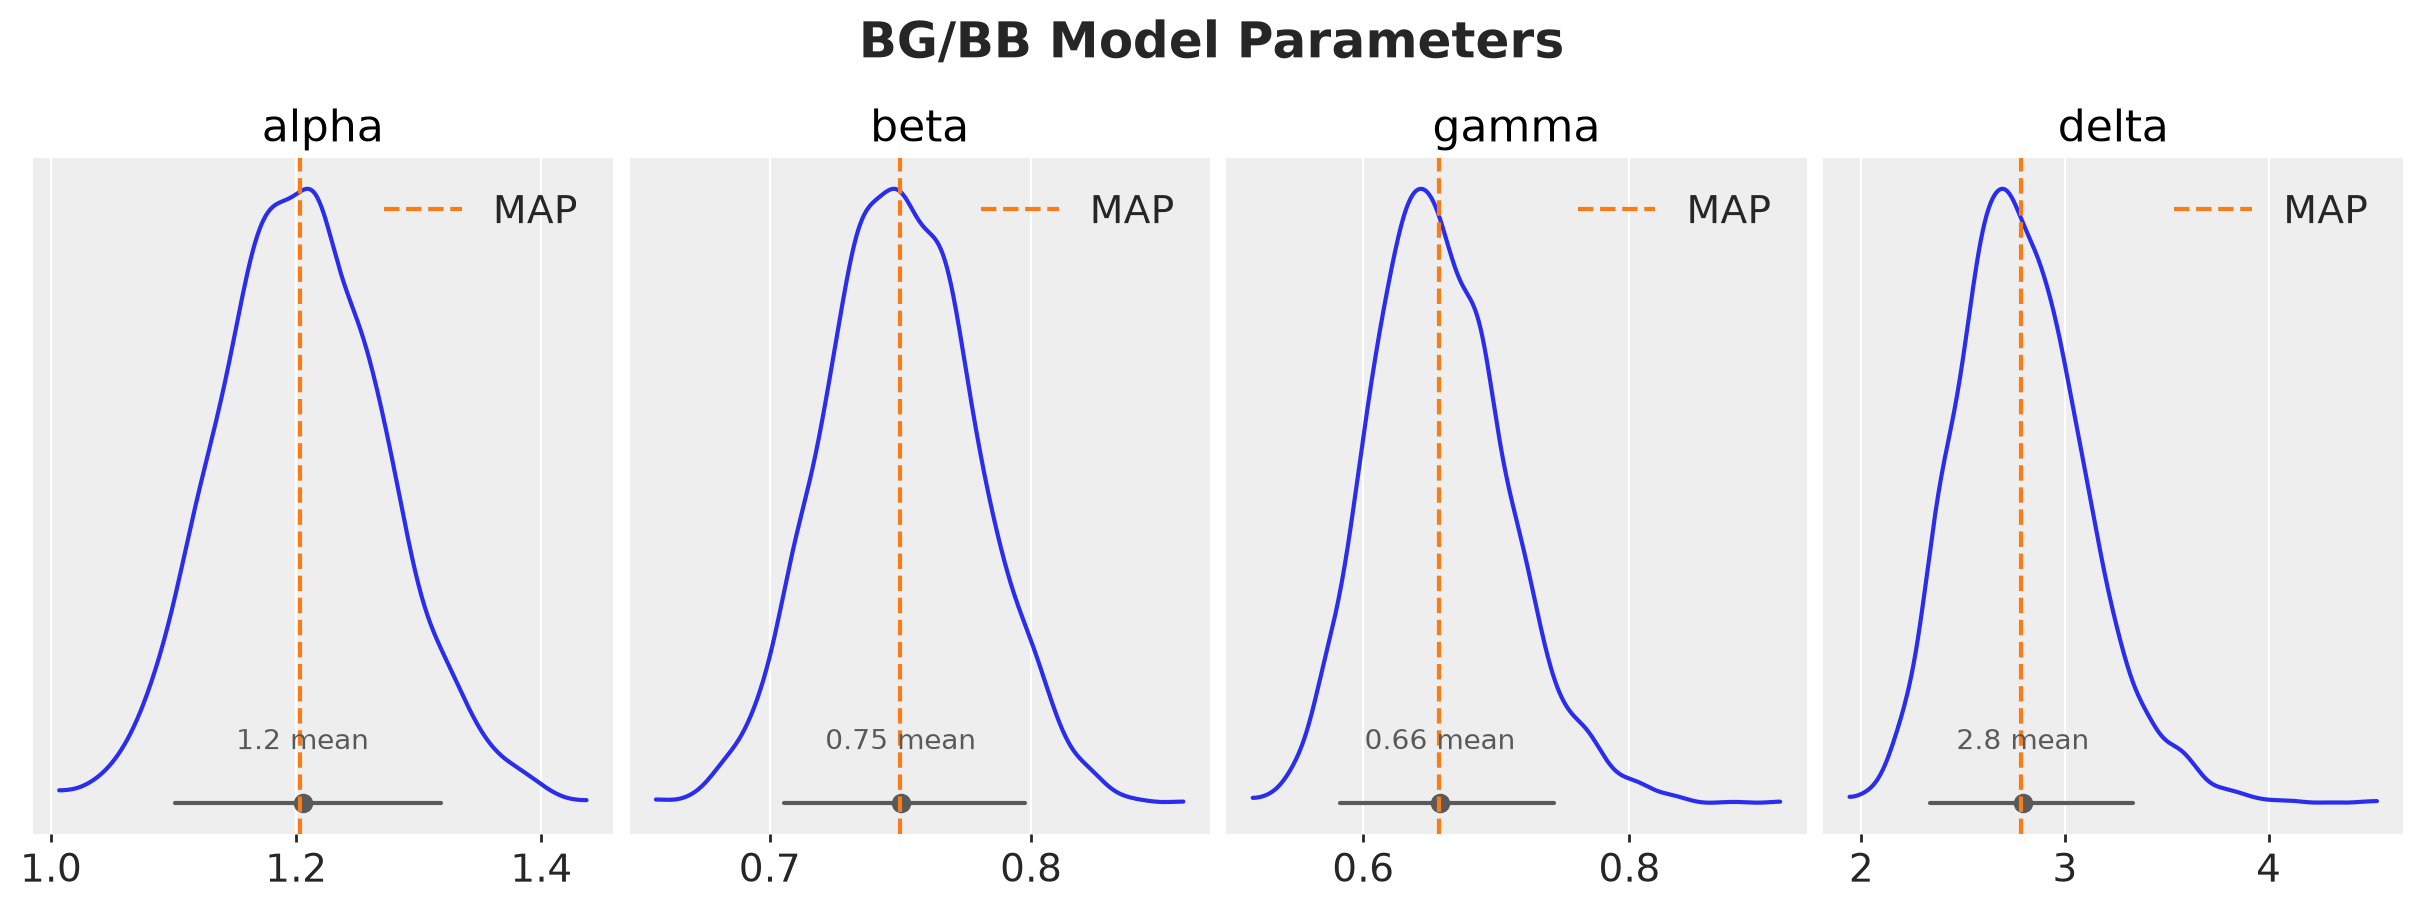

In [12]:
pc = azp.plot_dist(
    model.idata,
    var_names=["alpha", "beta", "gamma", "delta"],
    point_estimate="mean",
    figure_kwargs={"figsize": (12, 4)},
)

for var_name in ["alpha", "beta", "gamma", "delta"]:
    ax = pc.viz["plot"][var_name].item()
    ax.axvline(x=map_estimates[var_name], color="C1", linestyle="--", label="MAP")
    ax.legend(loc="upper right")

pc.viz["figure"].item().suptitle(
    "BG/BB Model Parameters", fontsize=18, fontweight="bold", y=1.1
);

## Posterior Predictive Check

We compare the observed number of donors with each repeat frequency against the posterior predictive distribution.

/home/pablo/Documents/repos-mios/pymc-marketing/.claude/worktrees/issue-1407-bgbb-notebook/.venv/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run beta_geo_beta_binom_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [recency_frequency]


Output()

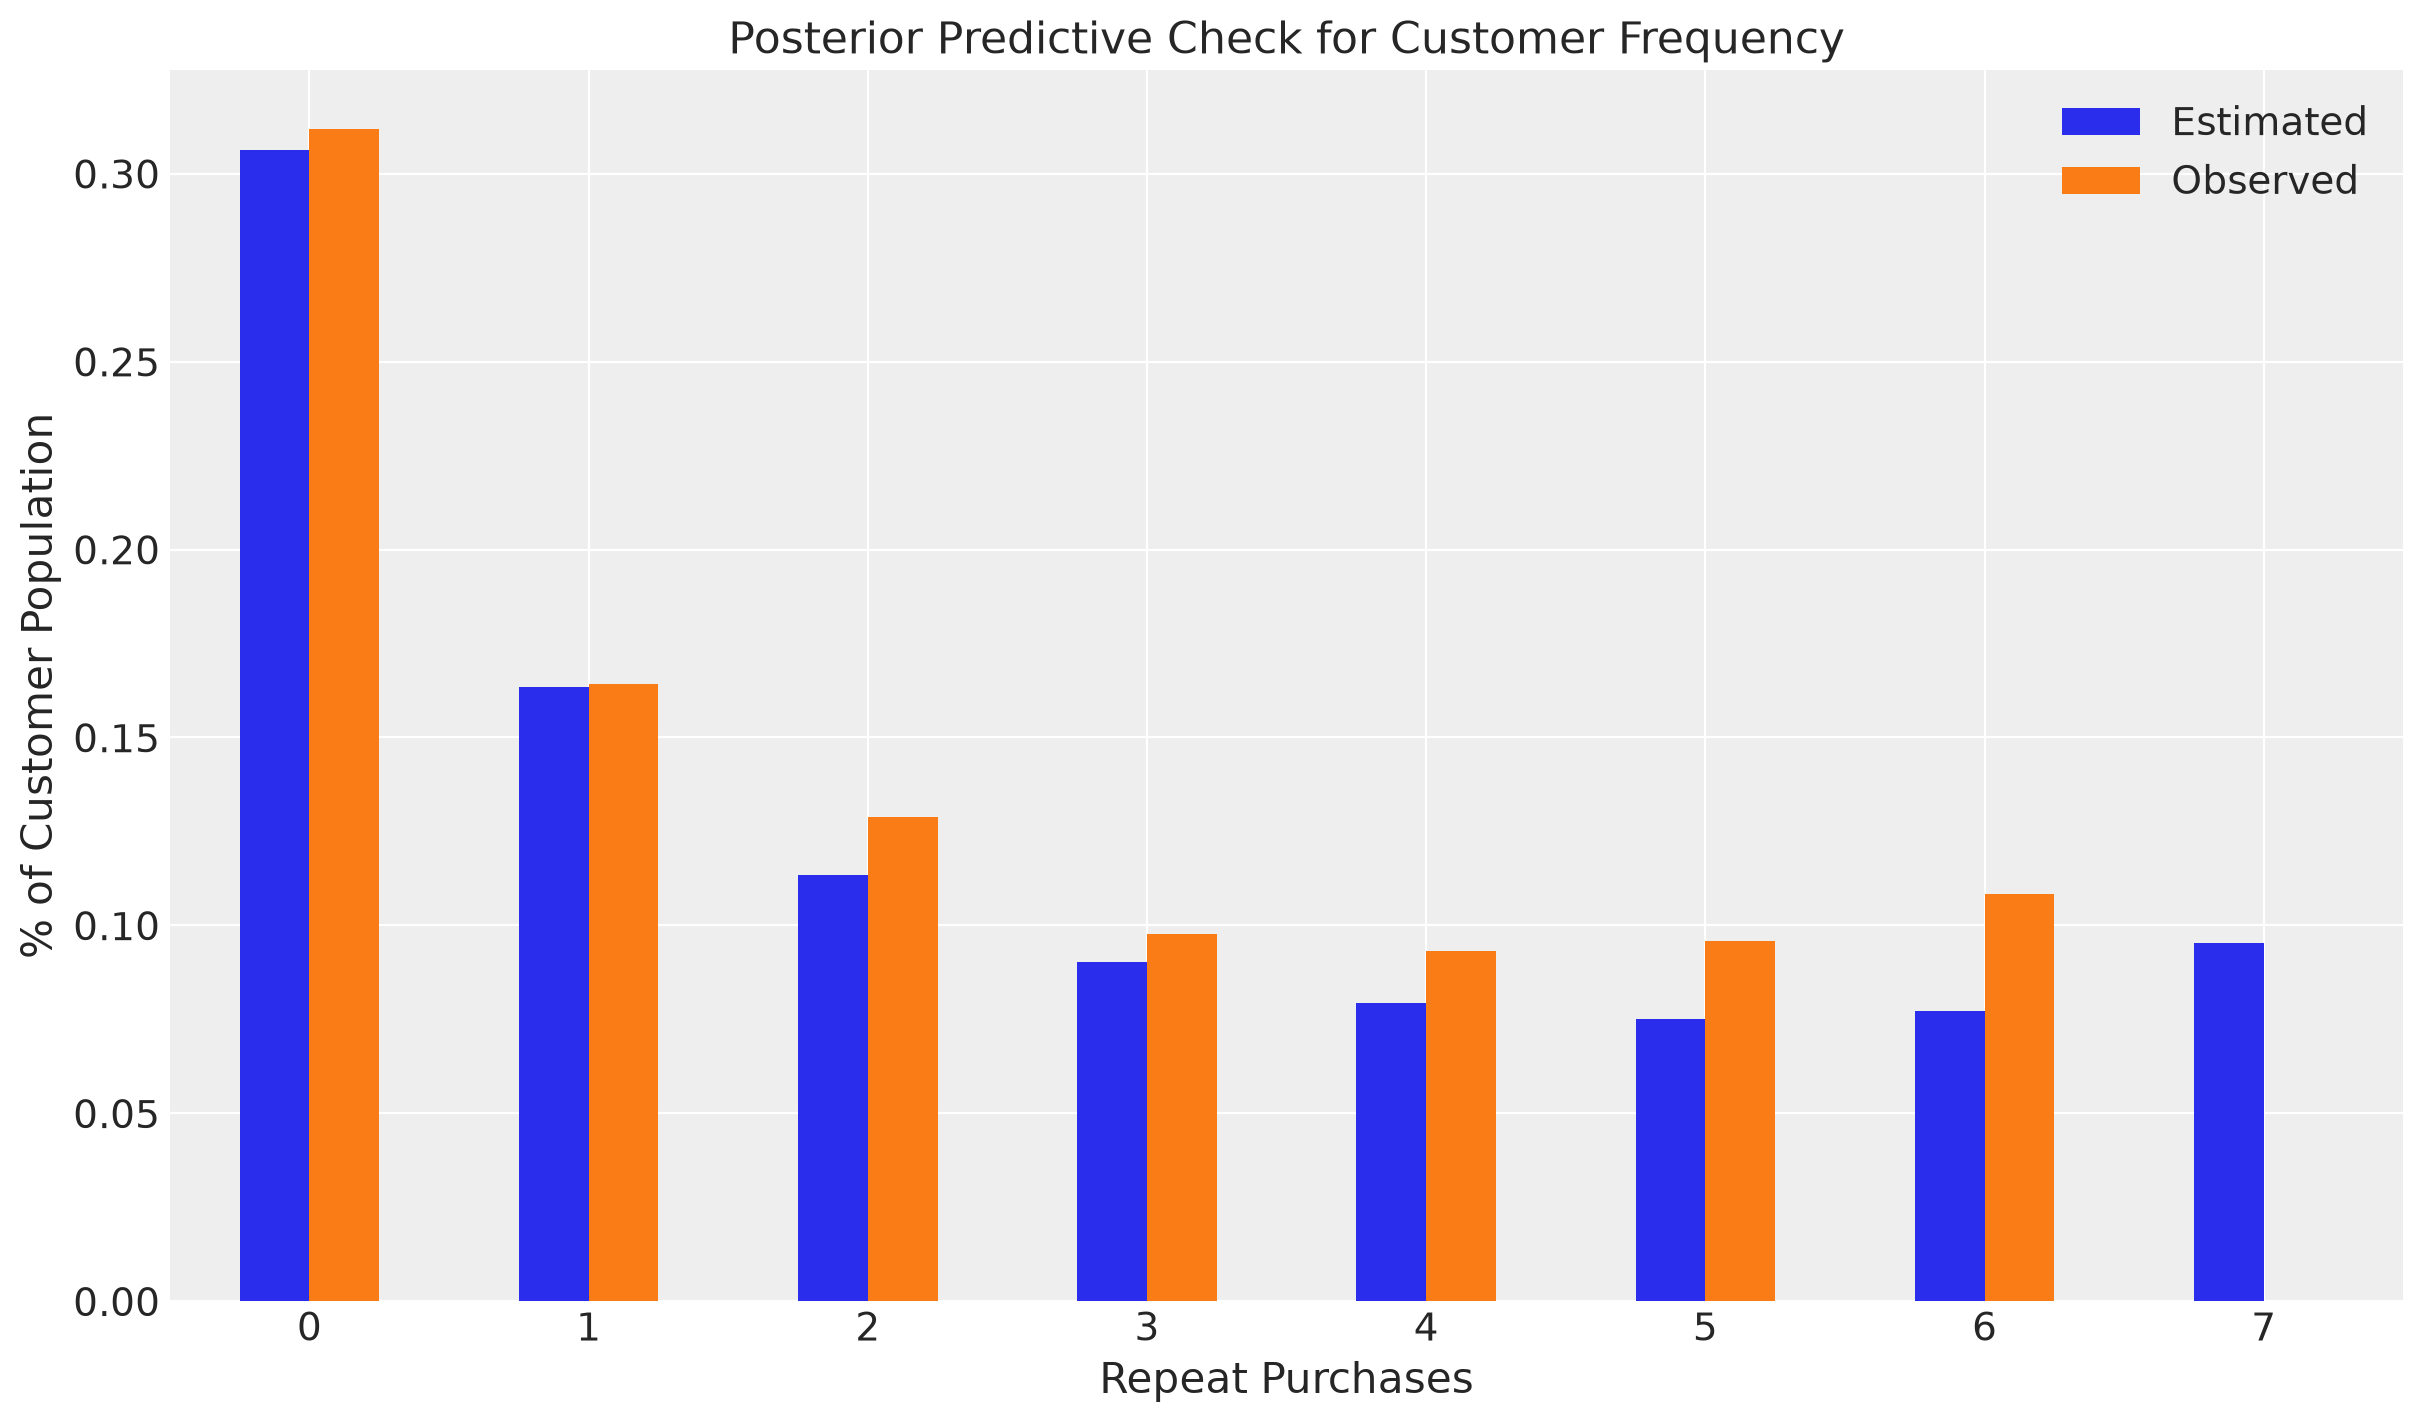

In [13]:
clv.plot_expected_purchases_ppc(model, ppc="posterior", random_seed=rng);

## Latent Purchase and Dropout Probabilities

The beta distributions for $p$ and $\theta$ describe how purchase and dropout probabilities vary across the donor base. We draw from both distributions for a new donor.

Sampling: [purchase_rate]


Output()

Sampling: [dropout]


Output()

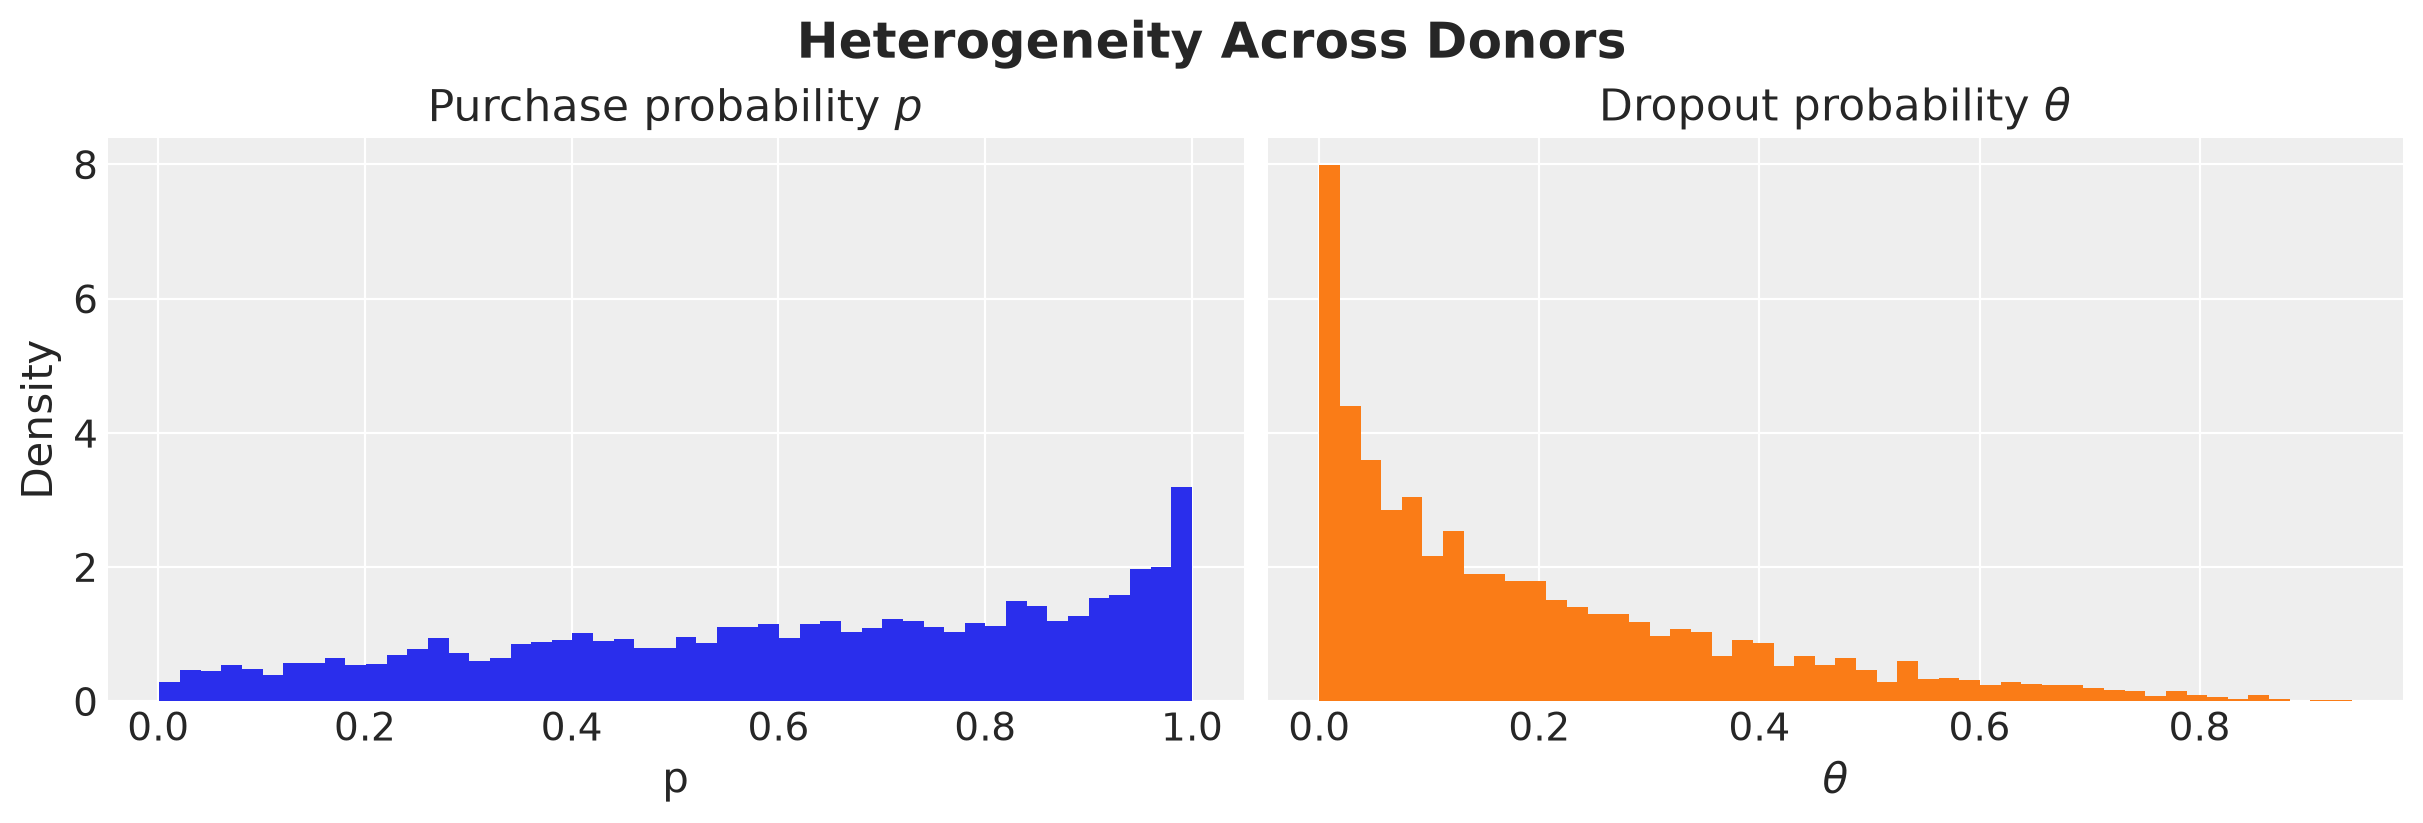

In [14]:
purchase_rate = model.distribution_new_customer_purchase_rate(random_seed=rng)
dropout = model.distribution_new_customer_dropout(random_seed=rng)

fig, axes = plt.subplots(ncols=2, figsize=(12, 4), sharey=True, layout="constrained")
axes[0].hist(purchase_rate.values.flatten(), bins=50, density=True)
axes[0].set(title="Purchase probability $p$", xlabel="p", ylabel="Density")
axes[1].hist(dropout.values.flatten(), bins=50, density=True, color="C1")
axes[1].set(title="Dropout probability $\\theta$", xlabel="$\\theta$")
fig.suptitle("Heterogeneity Across Donors", fontsize=18, fontweight="bold");

Since $\beta < 1$, the density of $p$ rises toward $p = 1$: many donors, while alive, donate in most years. Since $\gamma < 1$, the density of $\theta$ is highest near zero: most donors stay for a long time, and a smaller group leaves quickly.

## Predictions by Recency and Frequency

Since every donor falls into one of the 22 patterns, we can make predictions for the patterns instead of for all 11,104 donors. We predict:

- the expected number of repeat donations in the next five years (2002 to 2006), with `expected_purchases(future_t=5)`.
- the probability that a donor is still alive in 2002, with `expected_probability_alive(future_t=1)`.

In [15]:
patterns = (
    data.groupby(["frequency", "recency", "T"]).size().rename("n_donors").reset_index()
)
patterns["customer_id"] = np.arange(len(patterns))

expected_donations = model.expected_purchases(data=patterns, future_t=5)
probability_alive = model.expected_probability_alive(data=patterns, future_t=1)

patterns["expected_donations"] = expected_donations.mean(("chain", "draw")).values
patterns["probability_alive"] = probability_alive.mean(("chain", "draw")).values

The expected number of donations in 2002 to 2006, by frequency (rows) and recency (columns). These posterior means agree with Table 5 of the paper to within 0.01.

In [16]:
patterns.pivot(index="frequency", columns="recency", values="expected_donations").round(
    2
)

recency,0,1,2,3,4,5,6
frequency,,,,,,,
0,0.07,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,0.09,0.31,0.59,0.84,1.02,1.15
2,NaN,NaN,0.12,0.54,1.06,1.44,1.67
3,NaN,NaN,NaN,0.22,1.04,1.81,2.19
4,NaN,NaN,NaN,NaN,0.58,2.03,2.71
5,NaN,NaN,NaN,NaN,NaN,1.81,3.23
6,NaN,NaN,NaN,NaN,NaN,NaN,3.75


The probability that a donor is alive in 2002, in the same layout. These posterior means agree with Table 6 of the paper to within 0.01.

In [17]:
patterns.pivot(index="frequency", columns="recency", values="probability_alive").round(
    2
)

recency,0,1,2,3,4,5,6
frequency,,,,,,,
0,0.11,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,0.07,0.26,0.48,0.68,0.83,0.93
2,NaN,NaN,0.07,0.30,0.59,0.80,0.93
3,NaN,NaN,NaN,0.10,0.44,0.77,0.93
4,NaN,NaN,NaN,NaN,0.20,0.70,0.93
5,NaN,NaN,NaN,NaN,NaN,0.52,0.93
6,NaN,NaN,NaN,NaN,NaN,NaN,0.93


Both tables show the role of recency. A donor with four repeat donations whose last donation was in 2001 (`recency=6`) is expected to make about 2.7 donations in the next five years. A donor with five repeat donations whose last donation was in 2000 (`recency=5`) is expected to make only about 1.8, because that donor may have already left.

The same information is available as a heatmap with `plot_frequency_recency_matrix`.

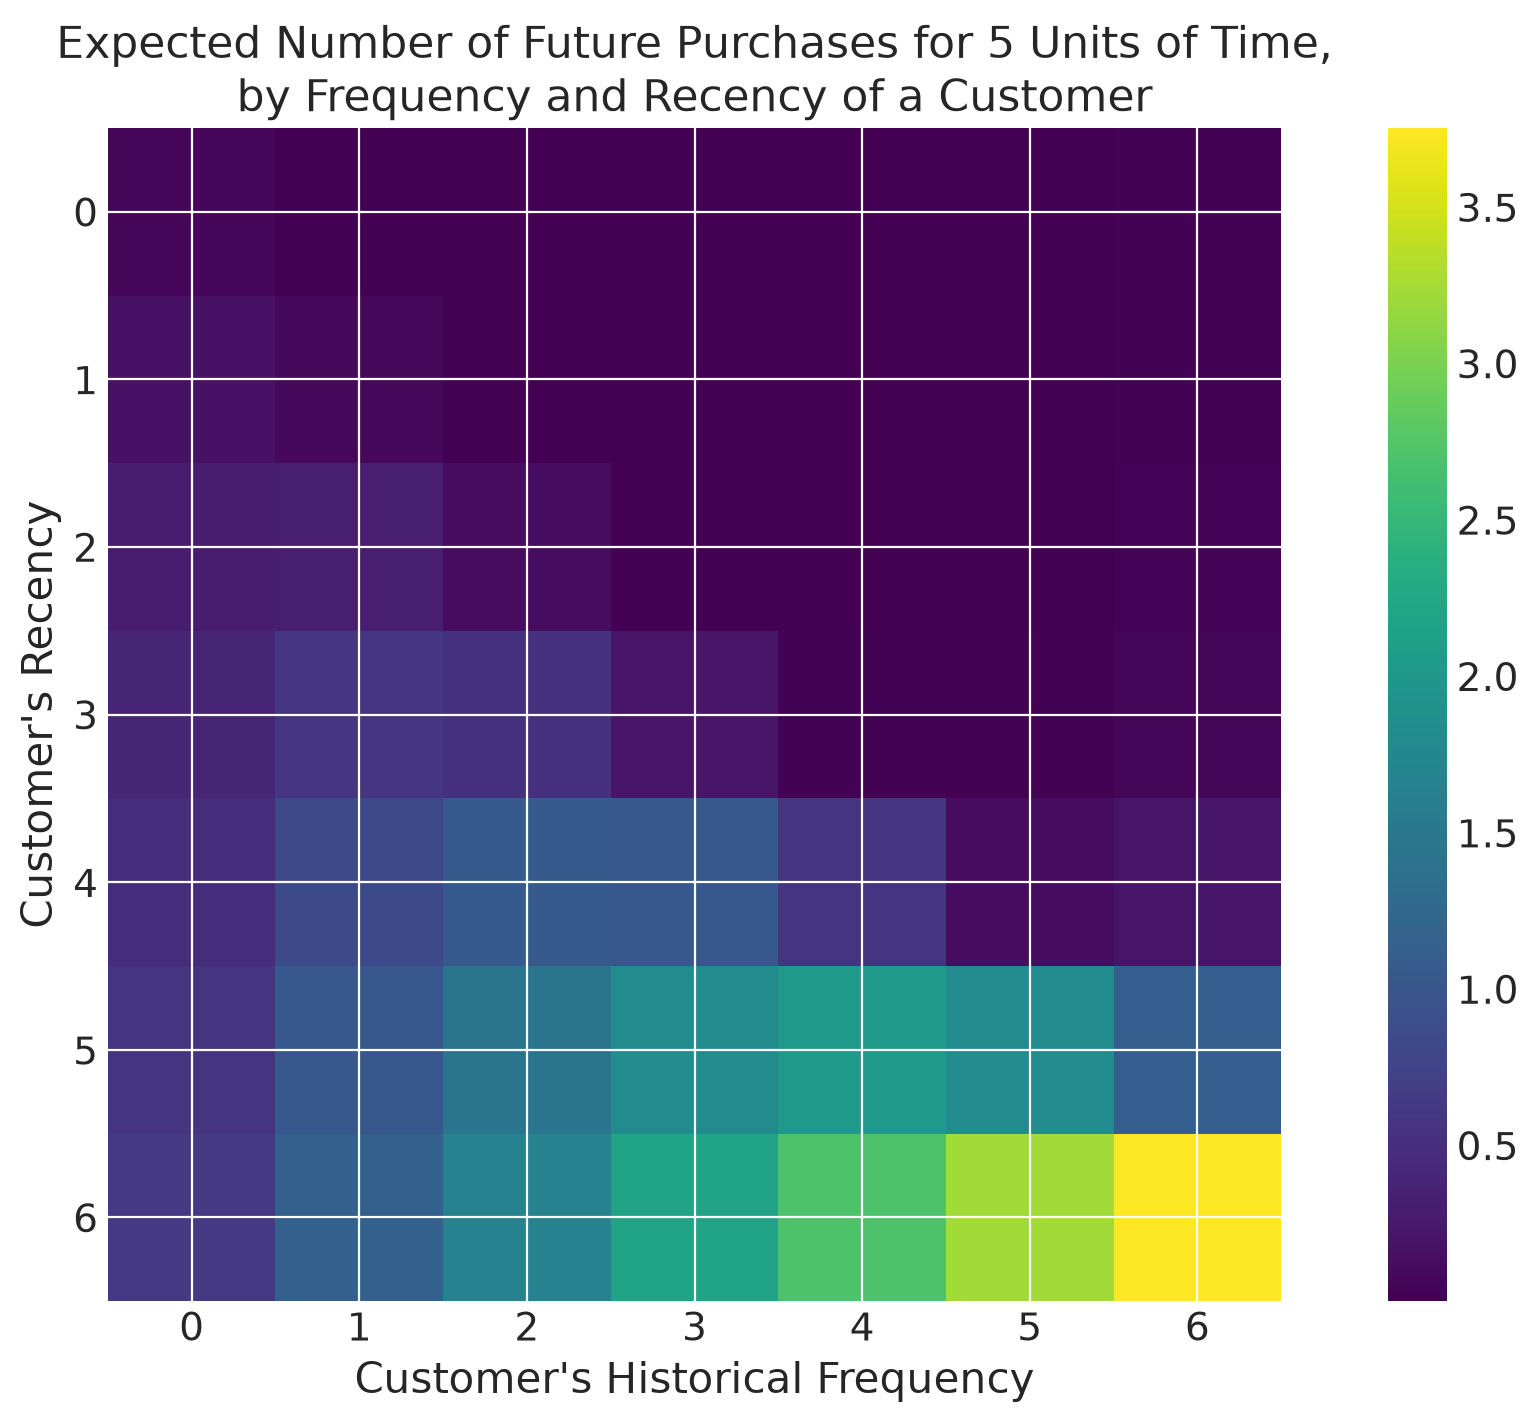

In [18]:
clv.plot_frequency_recency_matrix(model, future_t=5);

## Uncertainty for Individual Patterns

The posterior also gives the uncertainty for each prediction. Below we show the expected cumulative number of donations over the next ten years, with 94% HDI bands, for three patterns.

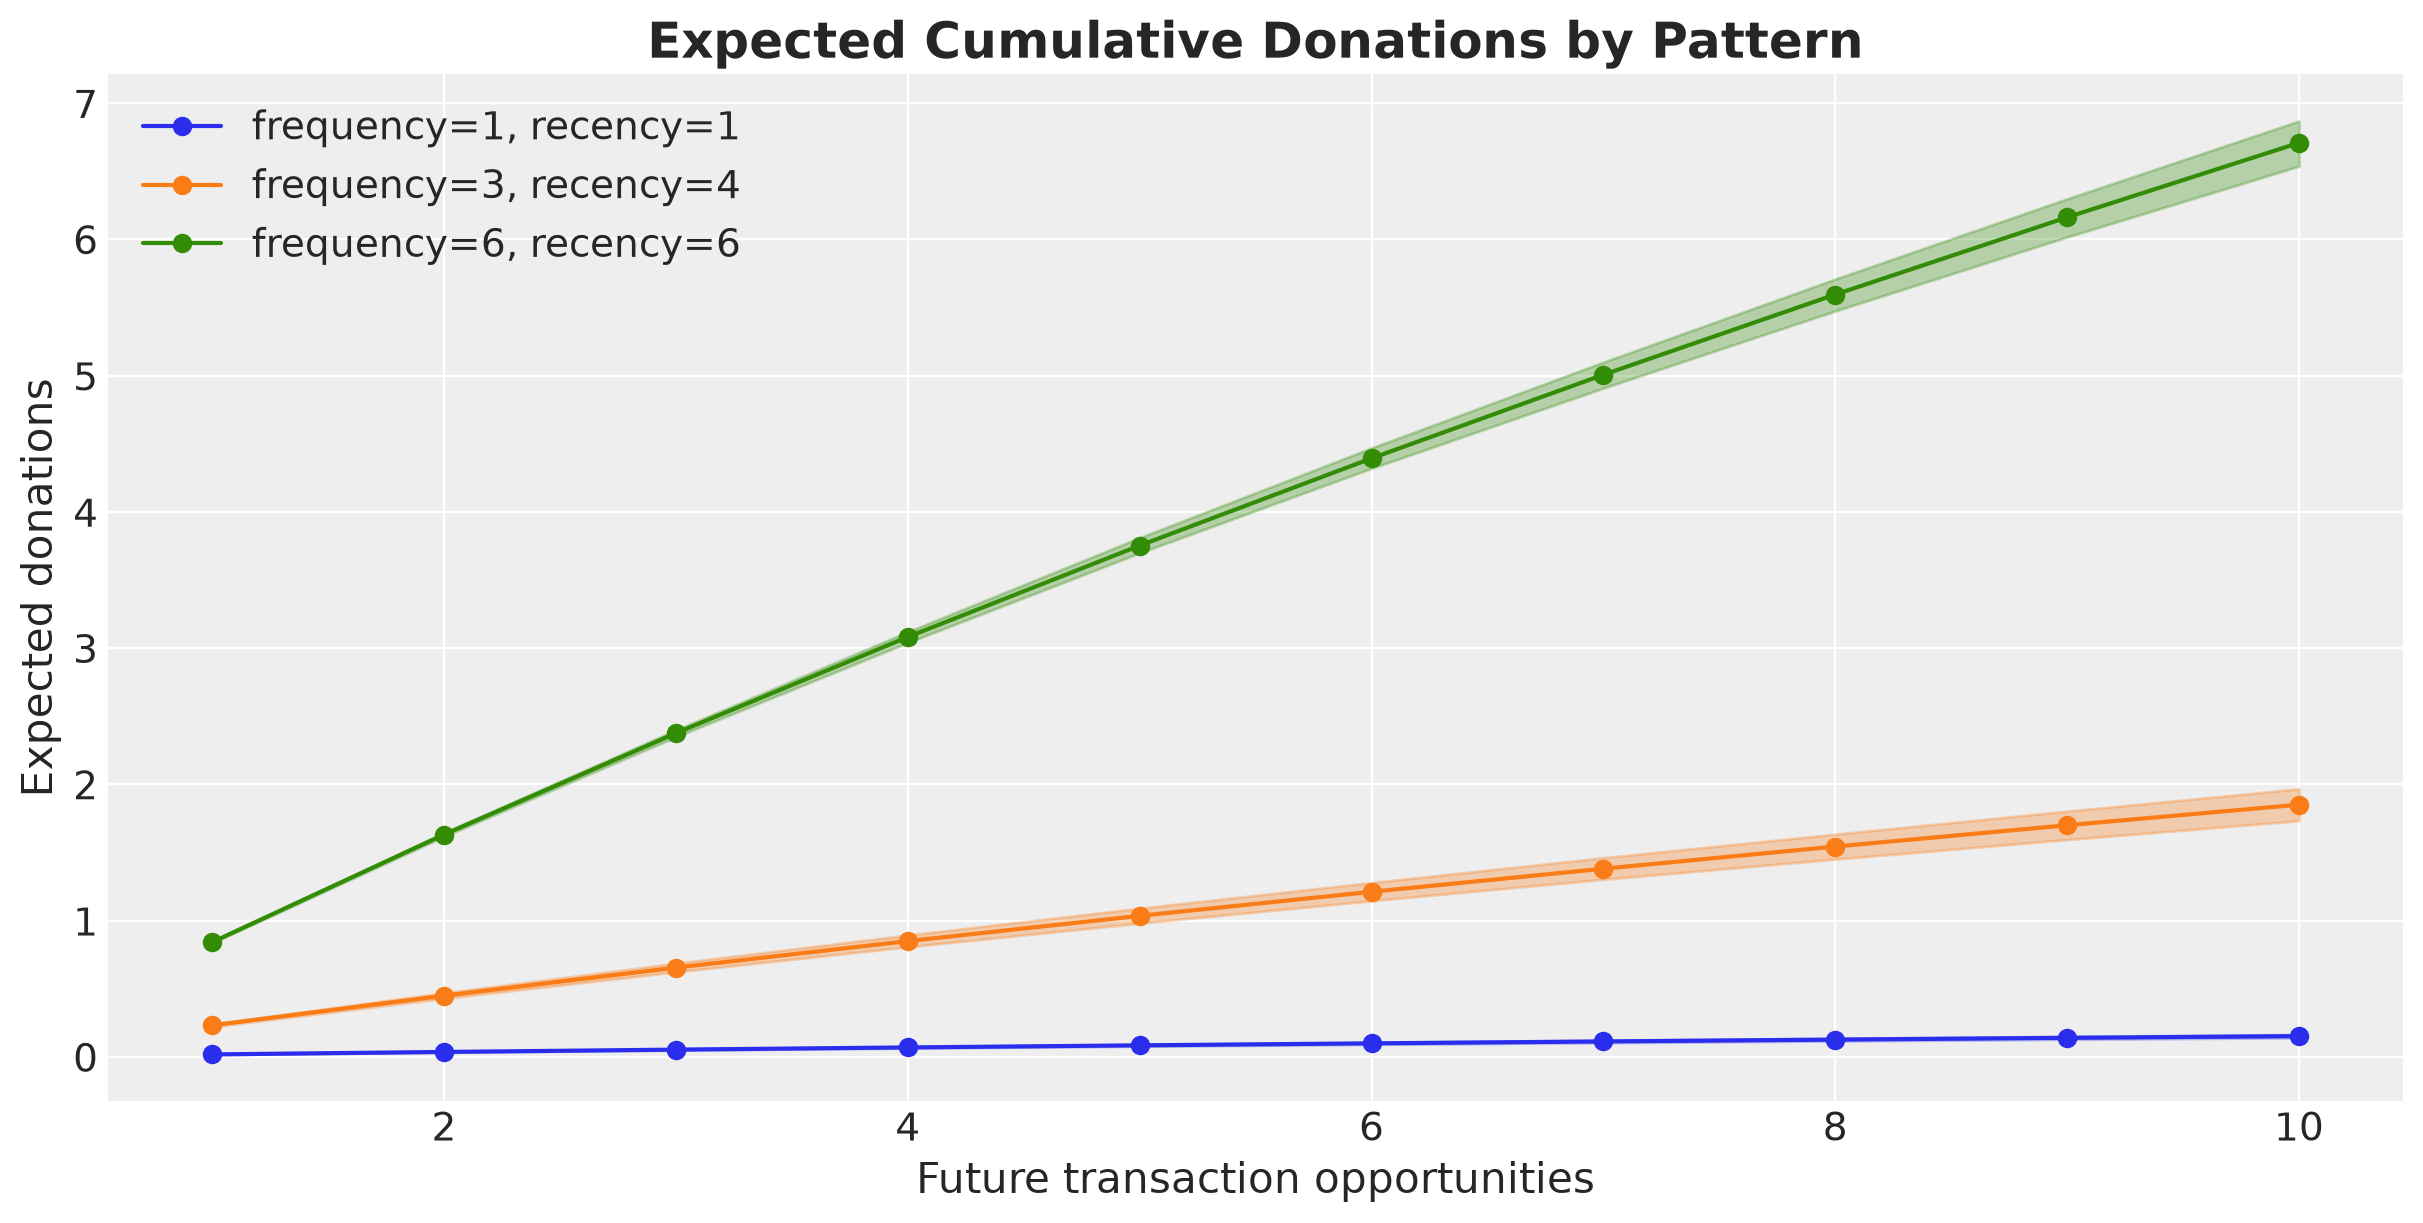

In [19]:
example_patterns = patterns.query(
    "(frequency == 6 and recency == 6) "
    "or (frequency == 3 and recency == 4) "
    "or (frequency == 1 and recency == 1)"
)
future_periods = np.arange(1, 11)

fig, ax = plt.subplots(figsize=(12, 6), layout="constrained")
for i, row in enumerate(example_patterns.itertuples()):
    pattern_data = pd.DataFrame(
        {
            "customer_id": future_periods,
            "frequency": row.frequency,
            "recency": row.recency,
            "T": row.T,
            "future_t": future_periods,
        }
    )
    expected = model.expected_purchases(data=pattern_data)
    hdi_94 = az.hdi(expected, prob=0.94)
    ax.fill_between(
        future_periods,
        hdi_94.sel(ci_bound="lower"),
        hdi_94.sel(ci_bound="upper"),
        color=f"C{i}",
        alpha=0.3,
    )
    ax.plot(
        future_periods,
        expected.mean(("chain", "draw")),
        color=f"C{i}",
        marker="o",
        label=f"frequency={row.frequency}, recency={row.recency}",
    )
ax.legend(loc="upper left")
ax.set(xlabel="Future transaction opportunities", ylabel="Expected donations")
ax.set_title(
    "Expected Cumulative Donations by Pattern", fontsize=18, fontweight="bold"
);

## New Donors

For a donor who has just been acquired, `expected_purchases_new_customer` gives the expected number of repeat donations over the first $t$ opportunities. The method returns one prediction per row of `data`, so we pass one row per value of $t$.

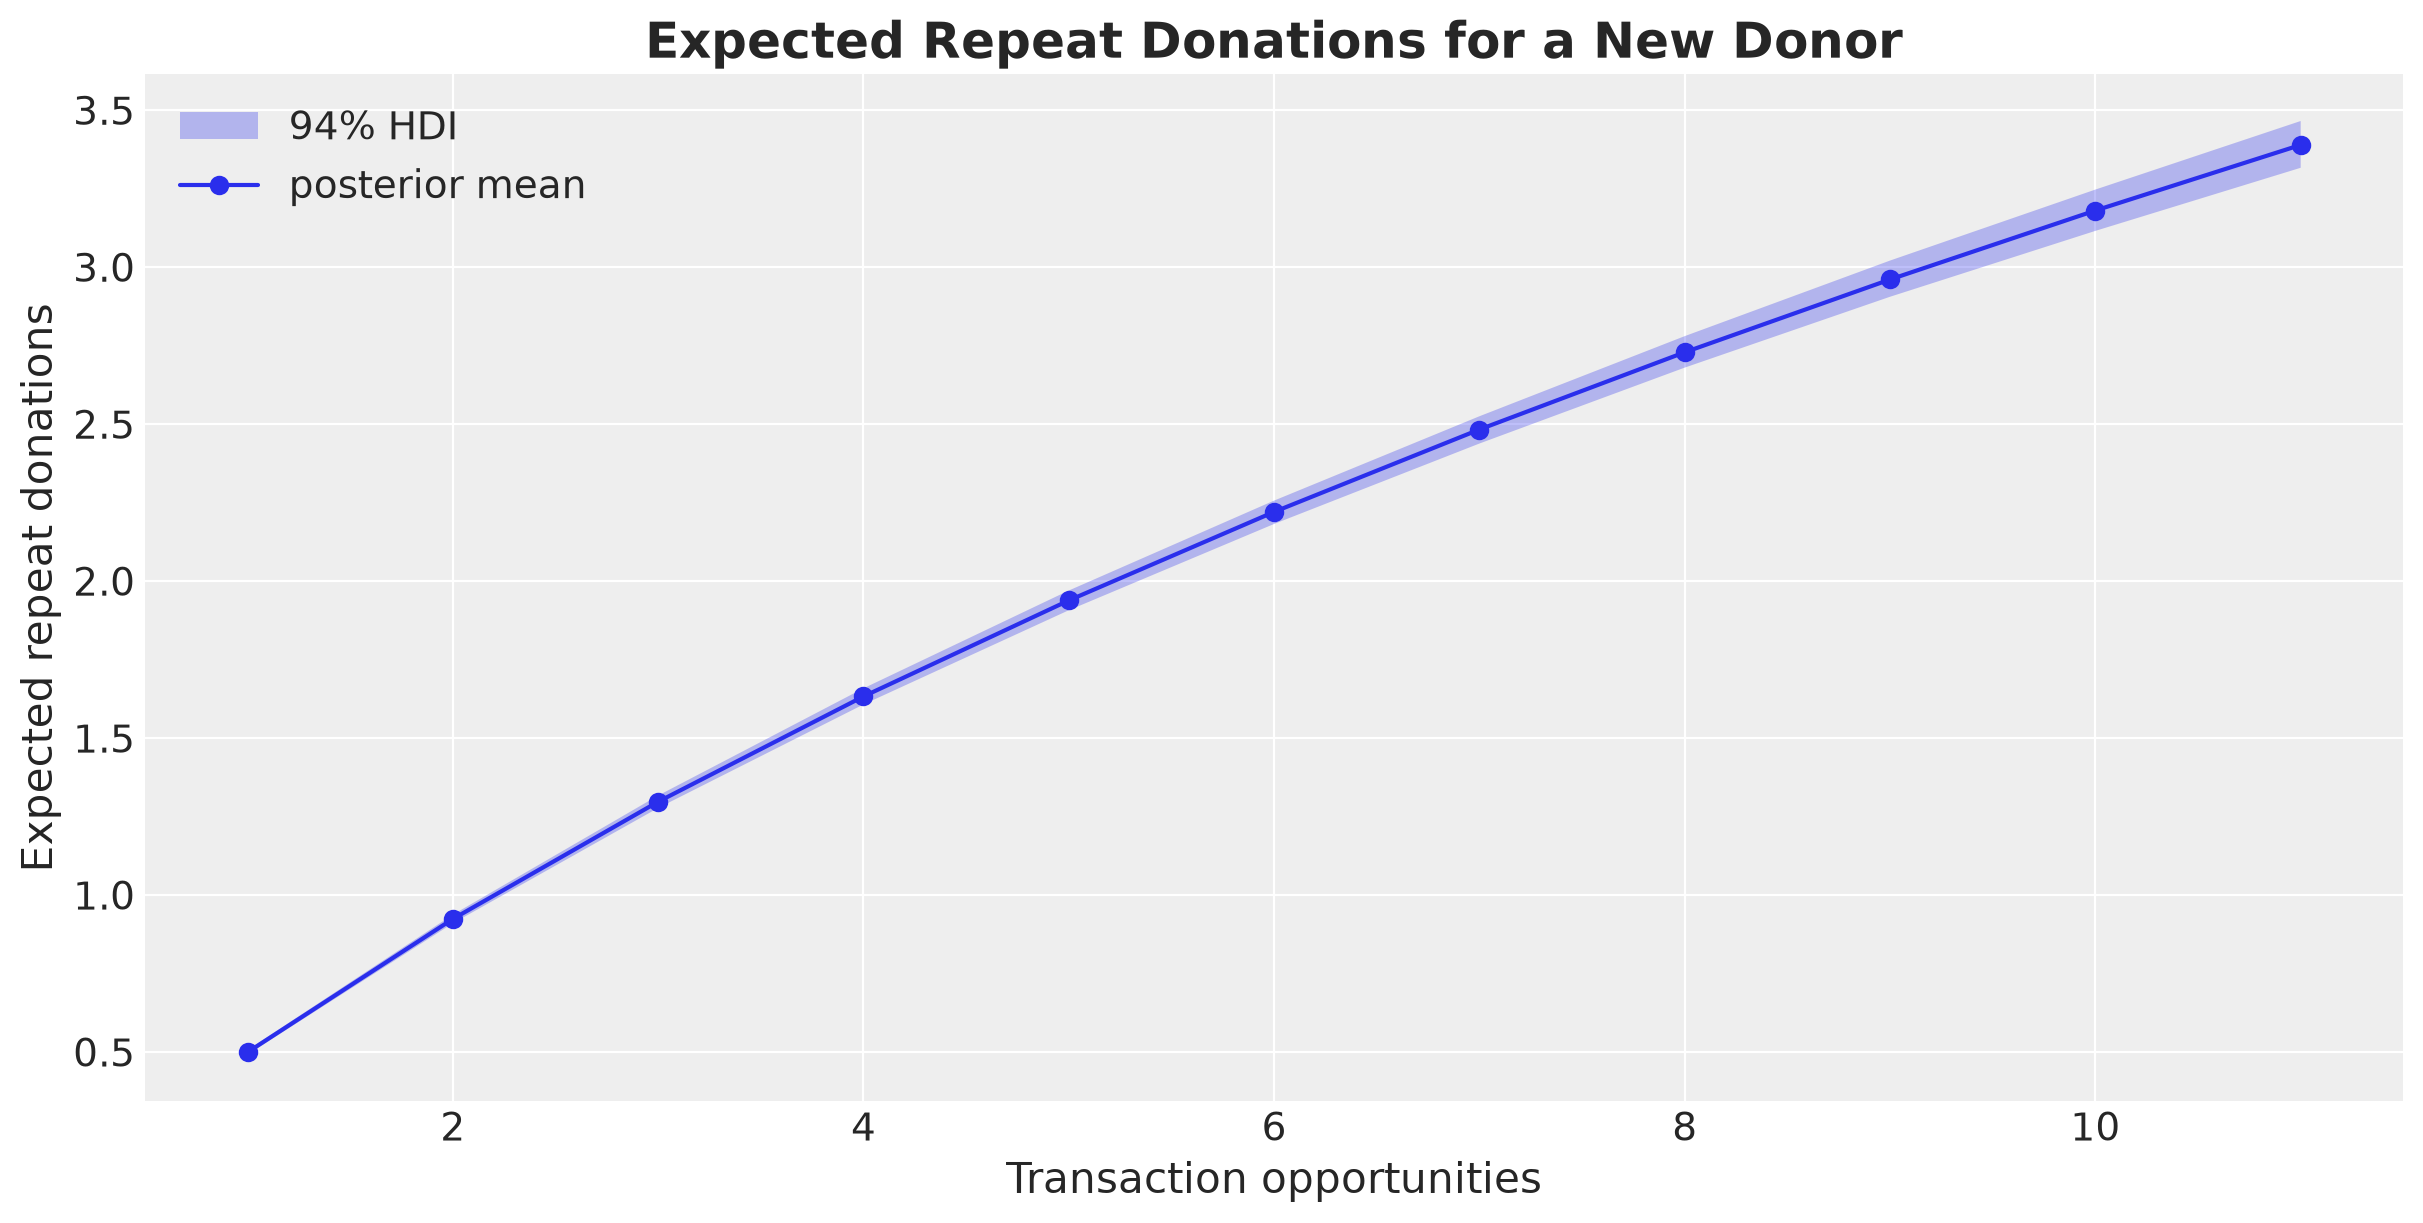

In [20]:
new_donor_periods = np.arange(1, 12)
new_donor_data = pd.DataFrame(
    {"customer_id": new_donor_periods, "t": new_donor_periods}
)
expected_new = model.expected_purchases_new_customer(data=new_donor_data)
hdi_94 = az.hdi(expected_new, prob=0.94)

fig, ax = plt.subplots(figsize=(12, 6), layout="constrained")
ax.fill_between(
    new_donor_periods,
    hdi_94.sel(ci_bound="lower"),
    hdi_94.sel(ci_bound="upper"),
    alpha=0.3,
    label="94% HDI",
)
ax.plot(
    new_donor_periods,
    expected_new.mean(("chain", "draw")),
    marker="o",
    label="posterior mean",
)
ax.legend(loc="upper left")
ax.set(xlabel="Transaction opportunities", ylabel="Expected repeat donations")
ax.set_title(
    "Expected Repeat Donations for a New Donor", fontsize=18, fontweight="bold"
);

In [21]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pymc,pytensor

Last updated: Mon, 28 Sep 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pymc          : 6.3.2
pytensor      : 3.3.2

arviz         : 1.2.0
arviz_plots   : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
pymc_extras   : 0.15.1
pymc_marketing: 1.1.0

Watermark: 2.6.0

